In [1]:
import os
import math

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

## pH Offset

In [2]:
nstep = pd.read_excel("./data/mCALR-N step data-17mar2026.xlsx", header = 1)
nstep = nstep[2:].reset_index(drop = True)
nstep.columns = ["Batch"] + nstep.columns.tolist()[1:]

nstep_ts = pd.read_excel("./data/mCALR-N step data-17mar2026.xlsx", sheet_name = 1, header = 1)
nstep_ts.insert(0, "Batch", nstep_ts["Run"].apply(lambda x: x.split("_")[0]))

nstep_ts_start = nstep_ts[["Batch", "Process Time [h]"]].groupby("Batch").min().reset_index()
nstep_ts_start.columns = ["Batch", "Process Start Time"]

nstep_ts = pd.merge(nstep_ts_start, nstep_ts, on = "Batch")
nstep_ts["Process Time [h]"] -= nstep_ts["Process Start Time"]
nstep_ts.insert(3, "Process Day", nstep_ts["Process Time [h]"].apply(lambda x: math.ceil((x - 12)/24)))
nstep_ts.drop("Process Start Time", axis = 1, inplace = True)

In [3]:
nminusstep_ts = pd.read_excel("./data/mCALR N-1.xlsx", sheet_name = 1)
nminusstep_ts.insert(0, "Batch", nminusstep_ts["Run"].apply(lambda x: x.split("_")[0]))

nminusstep_ts_start = nminusstep_ts[["Batch", "Process Time [h]"]].groupby("Batch").min().reset_index()
nminusstep_ts_start.columns = ["Batch", "Process Start Time"]

nminusstep_ts = pd.merge(nminusstep_ts_start, nminusstep_ts, on = "Batch")
nminusstep_ts["Process Time [h]"] -= nminusstep_ts["Process Start Time"]
nminusstep_ts.insert(3, "Process Day", nminusstep_ts["Process Time [h]"].apply(lambda x: math.ceil((x - 12)/24)))
nminusstep_ts.drop("Process Start Time", axis = 1, inplace = True)

In [4]:
target = nstep[["Batch", "STR2K_D14_4_1_PA_HPLC_Concentration"]]
target.columns = ["Batch", "D14 Titer"]
target

,Batch,D14 Titer
0,FA001,5.19
1,FA002,4.86
2,FA003,4.63
3,FA004,4.62
4,FA005,3.91
5,FA006,5.63
6,FA007,5.79
7,FA008,5.89
8,FA009,4.84
9,FA010,5.56


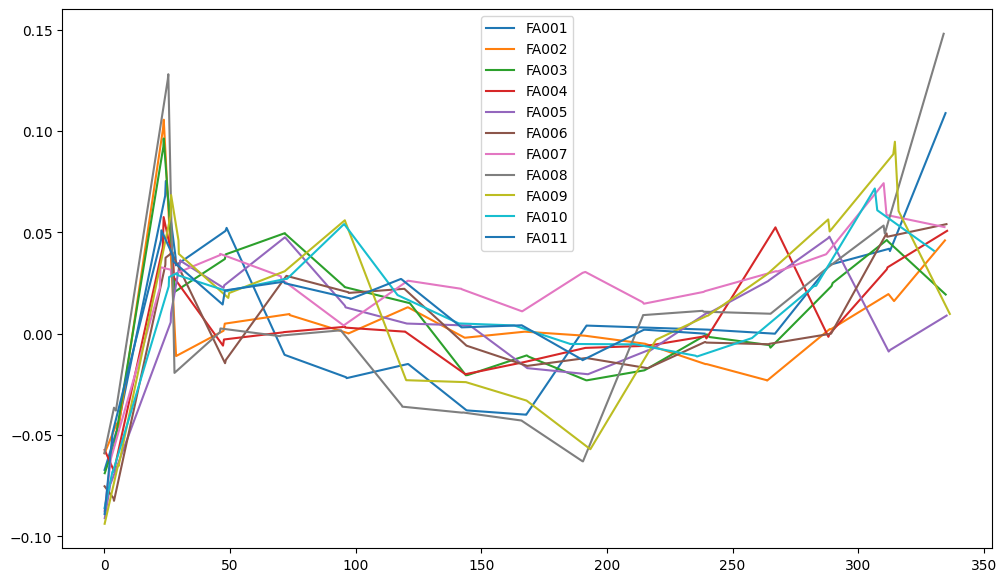

In [5]:
plt.figure(figsize = (12, 7))
for batch in nstep_ts["Batch"].unique():
    sub_df = nstep_ts[nstep_ts["Batch"] == batch].copy()
    sub_df = sub_df[["Process Day", "Process Time [h]","pH offset []"]]
    # sub_df = sub_df.groupby("Process Day").max().reset_index()
    sub_df = sub_df[~sub_df["pH offset []"].isna()]
    plt.plot(sub_df["Process Time [h]"], sub_df["pH offset []"], label = batch)
plt.legend()
plt.show()

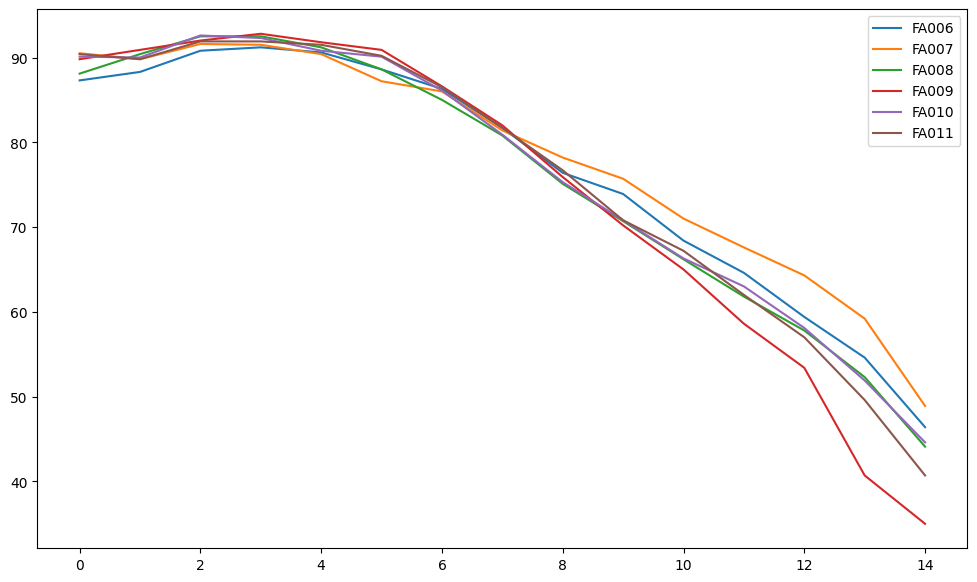

In [6]:
plt.figure(figsize = (12, 7))
for batch in nstep_ts["Batch"].unique()[5:]:
    sub_df = nstep_ts[nstep_ts["Batch"] == batch].copy()
    sub_df = sub_df[["Process Day", "Process Time [h]","Viability [%]"]]
    sub_df = sub_df.groupby("Process Day").max().reset_index()
    # sub_df = sub_df[~sub_df["pH offset []"].isna()]
    plt.plot(sub_df["Process Day"], sub_df["Viability [%]"], label = batch)
plt.legend()
plt.show()

In [7]:
nstep_ts.groupby(["Batch", "Process Day"]).max().reset_index()

,Batch,Process Day,Run,Process Time [h],Ammonia [mg/L],Bolus Feed A Daily Qty [kg],Bolus Glucose Daily Qty [kg],Bolus Feed B Daily Qty [kg],Glucose [mg/L],Glutamate [mg/L],...,Lactate [mg/L],LDH [dimensionless],Offline pH preadusjtement [dimensionless],Online pH primary probe preadusjtement [dimensionless],Online pH secondary probe preadusjtement [dimensionless],pCO2 preadusjtement [mmHg],pH offset [],pO2 preadusjtement [mmHg],VCD [Mc/mL],Viability [%]
0,FA001,0,FA001_MCALR N-PROD 2000L_1003145,7.383889,2.558,40.98,NaN,4.098,4798.96,102.85,...,214.43,113.8,7.047,7.04,7.05,101.0,-0.048199,136.1,7.53,91.5
1,FA001,1,FA001_MCALR N-PROD 2000L_1003145,28.489167,32.103,40.96,NaN,4.097,3288.72,383.90,...,2060.12,362.3,6.896,6.99,7.00,40.0,0.075332,32.1,12.03,89.0
2,FA001,2,FA001_MCALR N-PROD 2000L_1003145,51.487222,23.325,40.98,NaN,4.098,2767.70,503.73,...,1799.49,560.5,6.838,6.95,6.95,38.9,0.052195,15.1,19.19,89.7
3,FA001,3,FA001_MCALR N-PROD 2000L_1003145,73.599722,18.810,40.96,NaN,4.099,2161.62,546.30,...,1662.90,786.6,6.911,6.96,6.96,46.6,-0.010365,16.3,22.11,89.4
4,FA001,4,FA001_MCALR N-PROD 2000L_1003145,98.765556,20.666,40.98,9.66,4.098,1435.24,419.53,...,1114.41,1076.4,6.982,7.02,7.01,63.2,-0.021498,12.2,23.43,87.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
160,FA011,10,FA011_MCALR N-PROD 2000L_1004660,242.462222,136.388,46.40,12.60,4.635,1417.70,201.47,...,270.64,3832.5,6.990,7.05,7.05,150.0,0.000020,10.0,19.36,67.2
161,FA011,11,FA011_MCALR N-PROD 2000L_1004660,265.489167,130.870,46.40,NaN,4.634,2989.85,288.58,...,663.81,4231.6,6.960,7.04,7.03,130.2,NaN,10.0,17.35,62.0
162,FA011,12,FA011_MCALR N-PROD 2000L_1004660,289.369444,120.286,46.40,14.62,4.636,1218.24,367.30,...,1084.11,4852.7,6.938,7.03,7.03,92.8,NaN,14.4,17.28,57.0
163,FA011,13,FA011_MCALR N-PROD 2000L_1004660,315.898056,111.709,46.40,10.09,4.634,2351.06,463.96,...,2617.30,5296.8,6.699,6.87,6.87,38.6,NaN,21.7,14.00,49.6


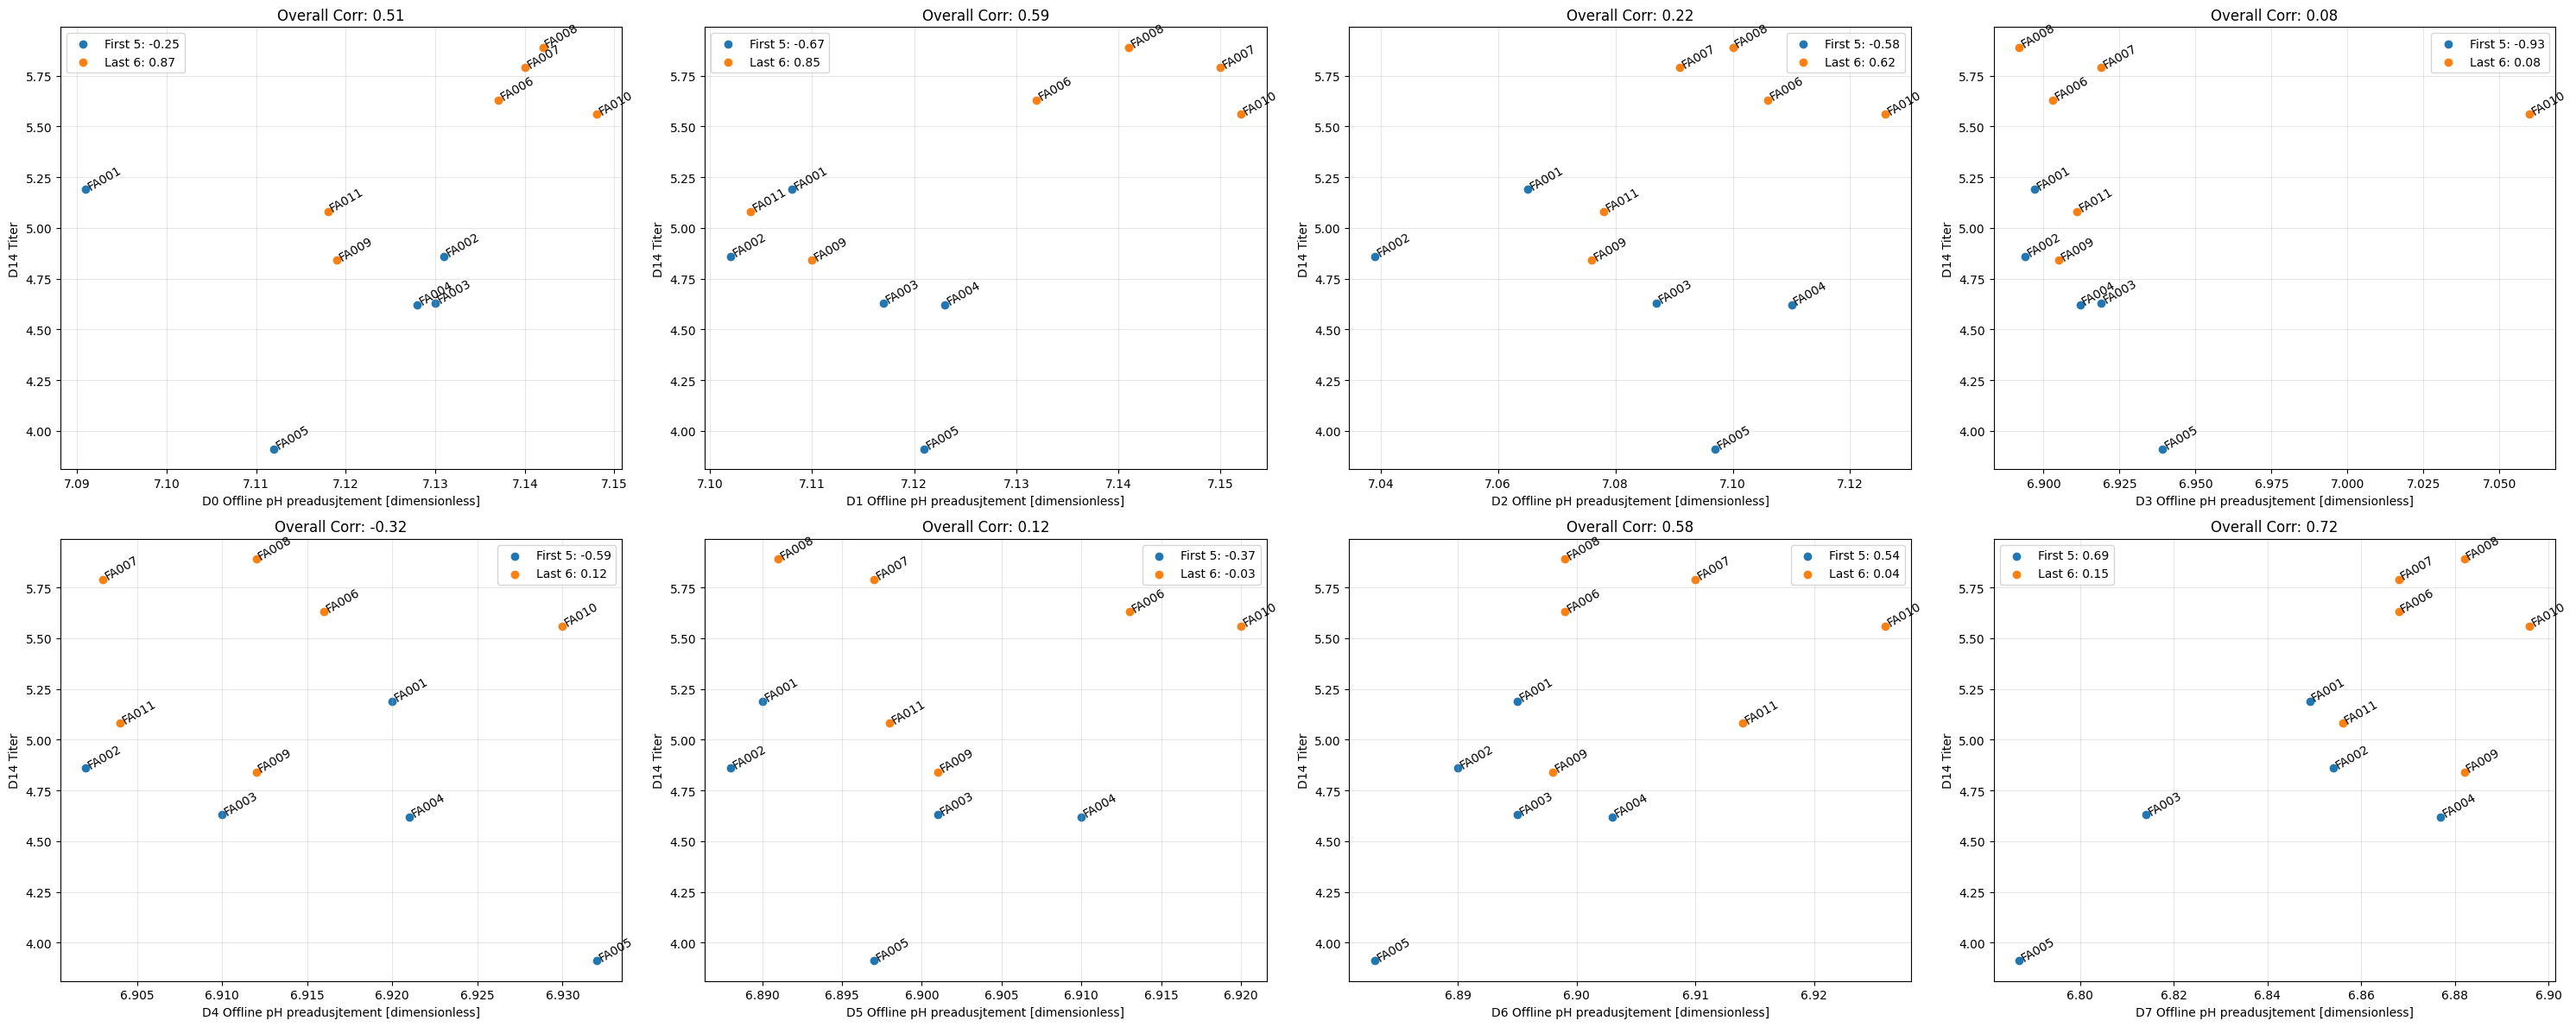

In [8]:
fig, axs = plt.subplots(2, 4, figsize = (30, 12))

feat = "Offline pH preadusjtement [dimensionless]"
nstep_ts_agg = nminusstep_ts.groupby(["Batch", "Process Day"]).max().reset_index()
nstep_ts_agg = pd.merge(target, nstep_ts_agg, on = "Batch")

first_batches = ["FA001", "FA002", "FA003", "FA004", "FA005"]

for day_idx, day in enumerate(nstep_ts_agg["Process Day"].unique()):

    row_idx = day_idx // 4
    col_idx = day_idx % 4
    ax = axs[row_idx][col_idx]

    sub_df = nstep_ts_agg[nstep_ts_agg["Process Day"] == day].copy()
    sub_df = sub_df.sort_values(by = "Batch")
    # sub_df = nstep_ts[nstep_ts["Batch"] == batch].copy()

    
    # sub_df = sub_df[["Process Day", "Process Time [h]","pH offset []"]]
    # sub_df = sub_df.groupby("Process Day").max().reset_index()
    sub_df = sub_df[~sub_df[feat].isna()]

    for row_idx, row in sub_df.iterrows():
        ax.text(row[feat], row["D14 Titer"], row["Batch"], rotation = 30)

    first_df = sub_df[sub_df["Batch"].isin(first_batches)]
    corr = np.corrcoef(first_df[feat].tolist(), first_df["D14 Titer"].tolist())[0, 1]
    ax.scatter(first_df[feat].tolist(), first_df["D14 Titer"].tolist(), label = f"First 5: {round(corr, 2)}")
    
    last_df = sub_df[~sub_df["Batch"].isin(first_batches)]
    corr = np.corrcoef(last_df[feat].tolist(), last_df["D14 Titer"].tolist())[0, 1]
    ax.scatter(last_df[feat].tolist(), last_df["D14 Titer"].tolist(), label = f"Last 6: {round(corr, 2)}")
    
    corr = np.corrcoef(sub_df[feat].tolist(), sub_df["D14 Titer"].tolist())[0, 1]
    
    ax.set_xlabel(f"D{day} {feat}")
    ax.set_ylabel("D14 Titer")
    # x_range = sub_df["pH offset []"].max() - sub_df["pH offset []"].min()
    ax.set_title(f"Overall Corr: {corr:.2f}")
    ax.legend()

    # ax.vlines(0, 0, 10, color = "red", linestyle = "--")
    # ax.set_ylim(3.811, 5.989)
    ax.grid(alpha = 0.3)

fig.tight_layout()
fig.show()

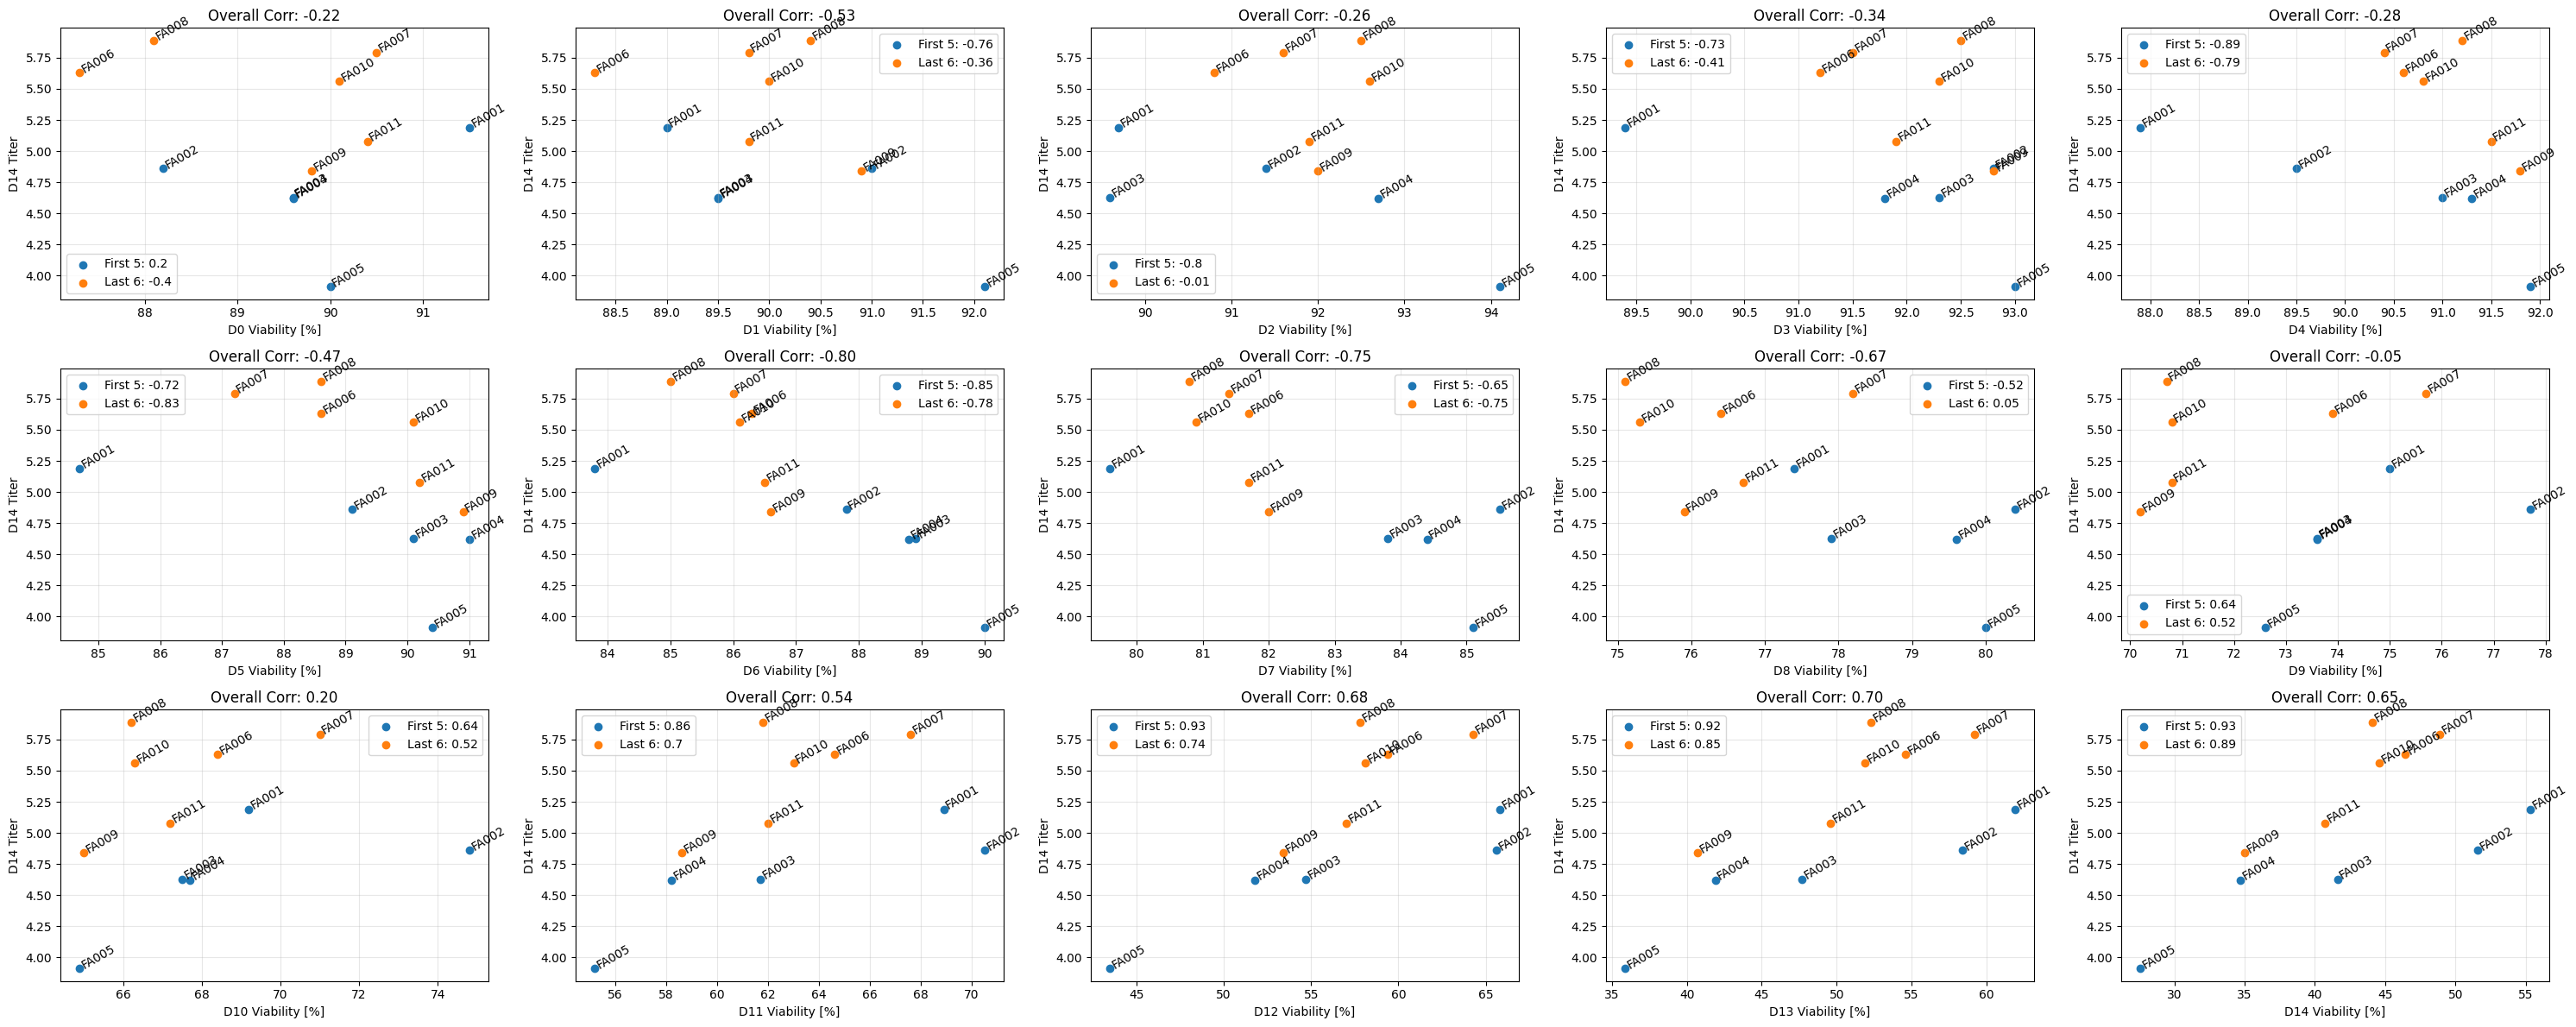

In [9]:
fig, axs = plt.subplots(3, 5, figsize = (30, 12))

feat = "Viability [%]"
nstep_ts_agg = nstep_ts.groupby(["Batch", "Process Day"]).max().reset_index()
nstep_ts_agg = pd.merge(target, nstep_ts_agg, on = "Batch")

first_batches = ["FA001", "FA002", "FA003", "FA004", "FA005"]

for day_idx, day in enumerate(nstep_ts["Process Day"].unique()):

    row_idx = day_idx // 5
    col_idx = day_idx % 5
    ax = axs[row_idx][col_idx]

    sub_df = nstep_ts_agg[nstep_ts_agg["Process Day"] == day].copy()
    sub_df = sub_df.sort_values(by = "Batch")
    # sub_df = nstep_ts[nstep_ts["Batch"] == batch].copy()

    
    # sub_df = sub_df[["Process Day", "Process Time [h]","pH offset []"]]
    # sub_df = sub_df.groupby("Process Day").max().reset_index()
    sub_df = sub_df[~sub_df[feat].isna()]

    for row_idx, row in sub_df.iterrows():
        ax.text(row[feat], row["D14 Titer"], row["Batch"], rotation = 30)

    first_df = sub_df[sub_df["Batch"].isin(first_batches)]
    corr = np.corrcoef(first_df[feat].tolist(), first_df["D14 Titer"].tolist())[0, 1]
    ax.scatter(first_df[feat].tolist(), first_df["D14 Titer"].tolist(), label = f"First 5: {round(corr, 2)}")
    
    last_df = sub_df[~sub_df["Batch"].isin(first_batches)]
    corr = np.corrcoef(last_df[feat].tolist(), last_df["D14 Titer"].tolist())[0, 1]
    ax.scatter(last_df[feat].tolist(), last_df["D14 Titer"].tolist(), label = f"Last 6: {round(corr, 2)}")
    
    corr = np.corrcoef(sub_df[feat].tolist(), sub_df["D14 Titer"].tolist())[0, 1]
    
    ax.set_xlabel(f"D{day} {feat}")
    ax.set_ylabel("D14 Titer")
    # x_range = sub_df["pH offset []"].max() - sub_df["pH offset []"].min()
    ax.set_title(f"Overall Corr: {corr:.2f}")
    ax.legend()

    # ax.vlines(0, 0, 10, color = "red", linestyle = "--")
    # ax.set_ylim(3.811, 5.989)
    ax.grid(alpha = 0.3)

fig.tight_layout()
fig.show()

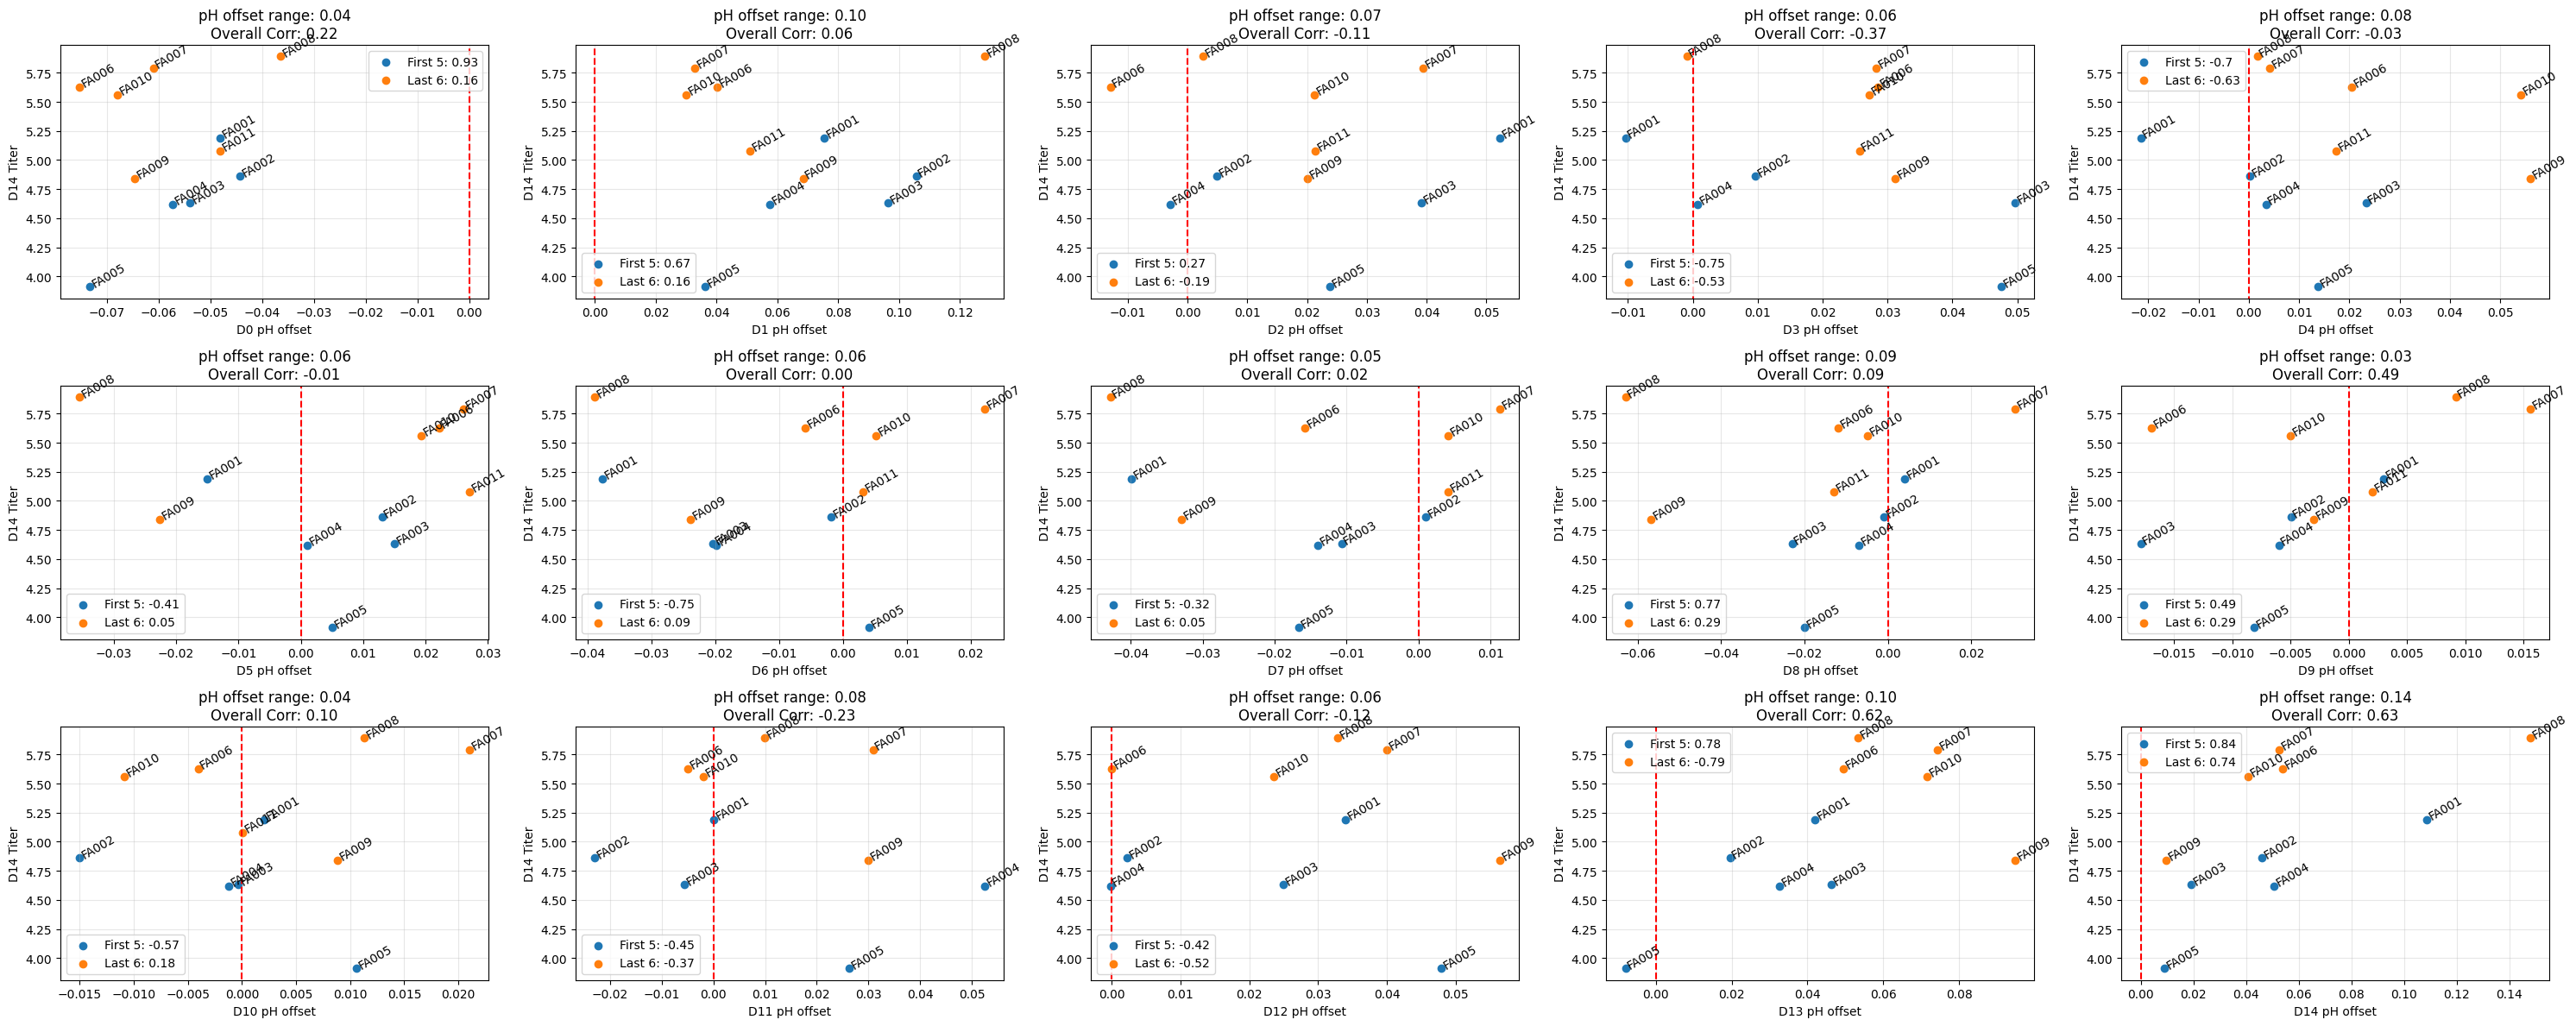

In [10]:
fig, axs = plt.subplots(3, 5, figsize = (30, 12))

feat = "pH offset []"
nstep_ts_agg = nstep_ts.groupby(["Batch", "Process Day"]).max().reset_index()
nstep_ts_agg = pd.merge(target, nstep_ts_agg, on = "Batch")

first_batches = ["FA001", "FA002", "FA003", "FA004", "FA005"]

for day_idx, day in enumerate(nstep_ts["Process Day"].unique()):

    row_idx = day_idx // 5
    col_idx = day_idx % 5
    ax = axs[row_idx][col_idx]

    sub_df = nstep_ts_agg[nstep_ts_agg["Process Day"] == day].copy()
    sub_df = sub_df.sort_values(by = "Batch")
    # sub_df = nstep_ts[nstep_ts["Batch"] == batch].copy()

    
    # sub_df = sub_df[["Process Day", "Process Time [h]","pH offset []"]]
    # sub_df = sub_df.groupby("Process Day").max().reset_index()
    sub_df = sub_df[~sub_df["pH offset []"].isna()]

    for row_idx, row in sub_df.iterrows():
        ax.text(row[feat], row["D14 Titer"], row["Batch"], rotation = 30)

    first_df = sub_df[sub_df["Batch"].isin(first_batches)]
    corr = np.corrcoef(first_df[feat].tolist(), first_df["D14 Titer"].tolist())[0, 1]
    ax.scatter(first_df[feat].tolist(), first_df["D14 Titer"].tolist(), label = f"First 5: {round(corr, 2)}")
    
    last_df = sub_df[~sub_df["Batch"].isin(first_batches)]
    corr = np.corrcoef(last_df[feat].tolist(), last_df["D14 Titer"].tolist())[0, 1]
    ax.scatter(last_df[feat].tolist(), last_df["D14 Titer"].tolist(), label = f"Last 6: {round(corr, 2)}")
    
    corr = np.corrcoef(sub_df[feat].tolist(), sub_df["D14 Titer"].tolist())[0, 1]
    
    ax.set_xlabel(f"D{day} pH offset")
    ax.set_ylabel("D14 Titer")
    x_range = sub_df["pH offset []"].max() - sub_df["pH offset []"].min()
    ax.set_title(f"pH offset range: {x_range:.2f}\nOverall Corr: {corr:.2f}")
    ax.legend()

    ax.vlines(0, 0, 10, color = "red", linestyle = "--")
    ax.set_ylim(3.811, 5.989)
    ax.grid(alpha = 0.3)

fig.tight_layout()
fig.show()

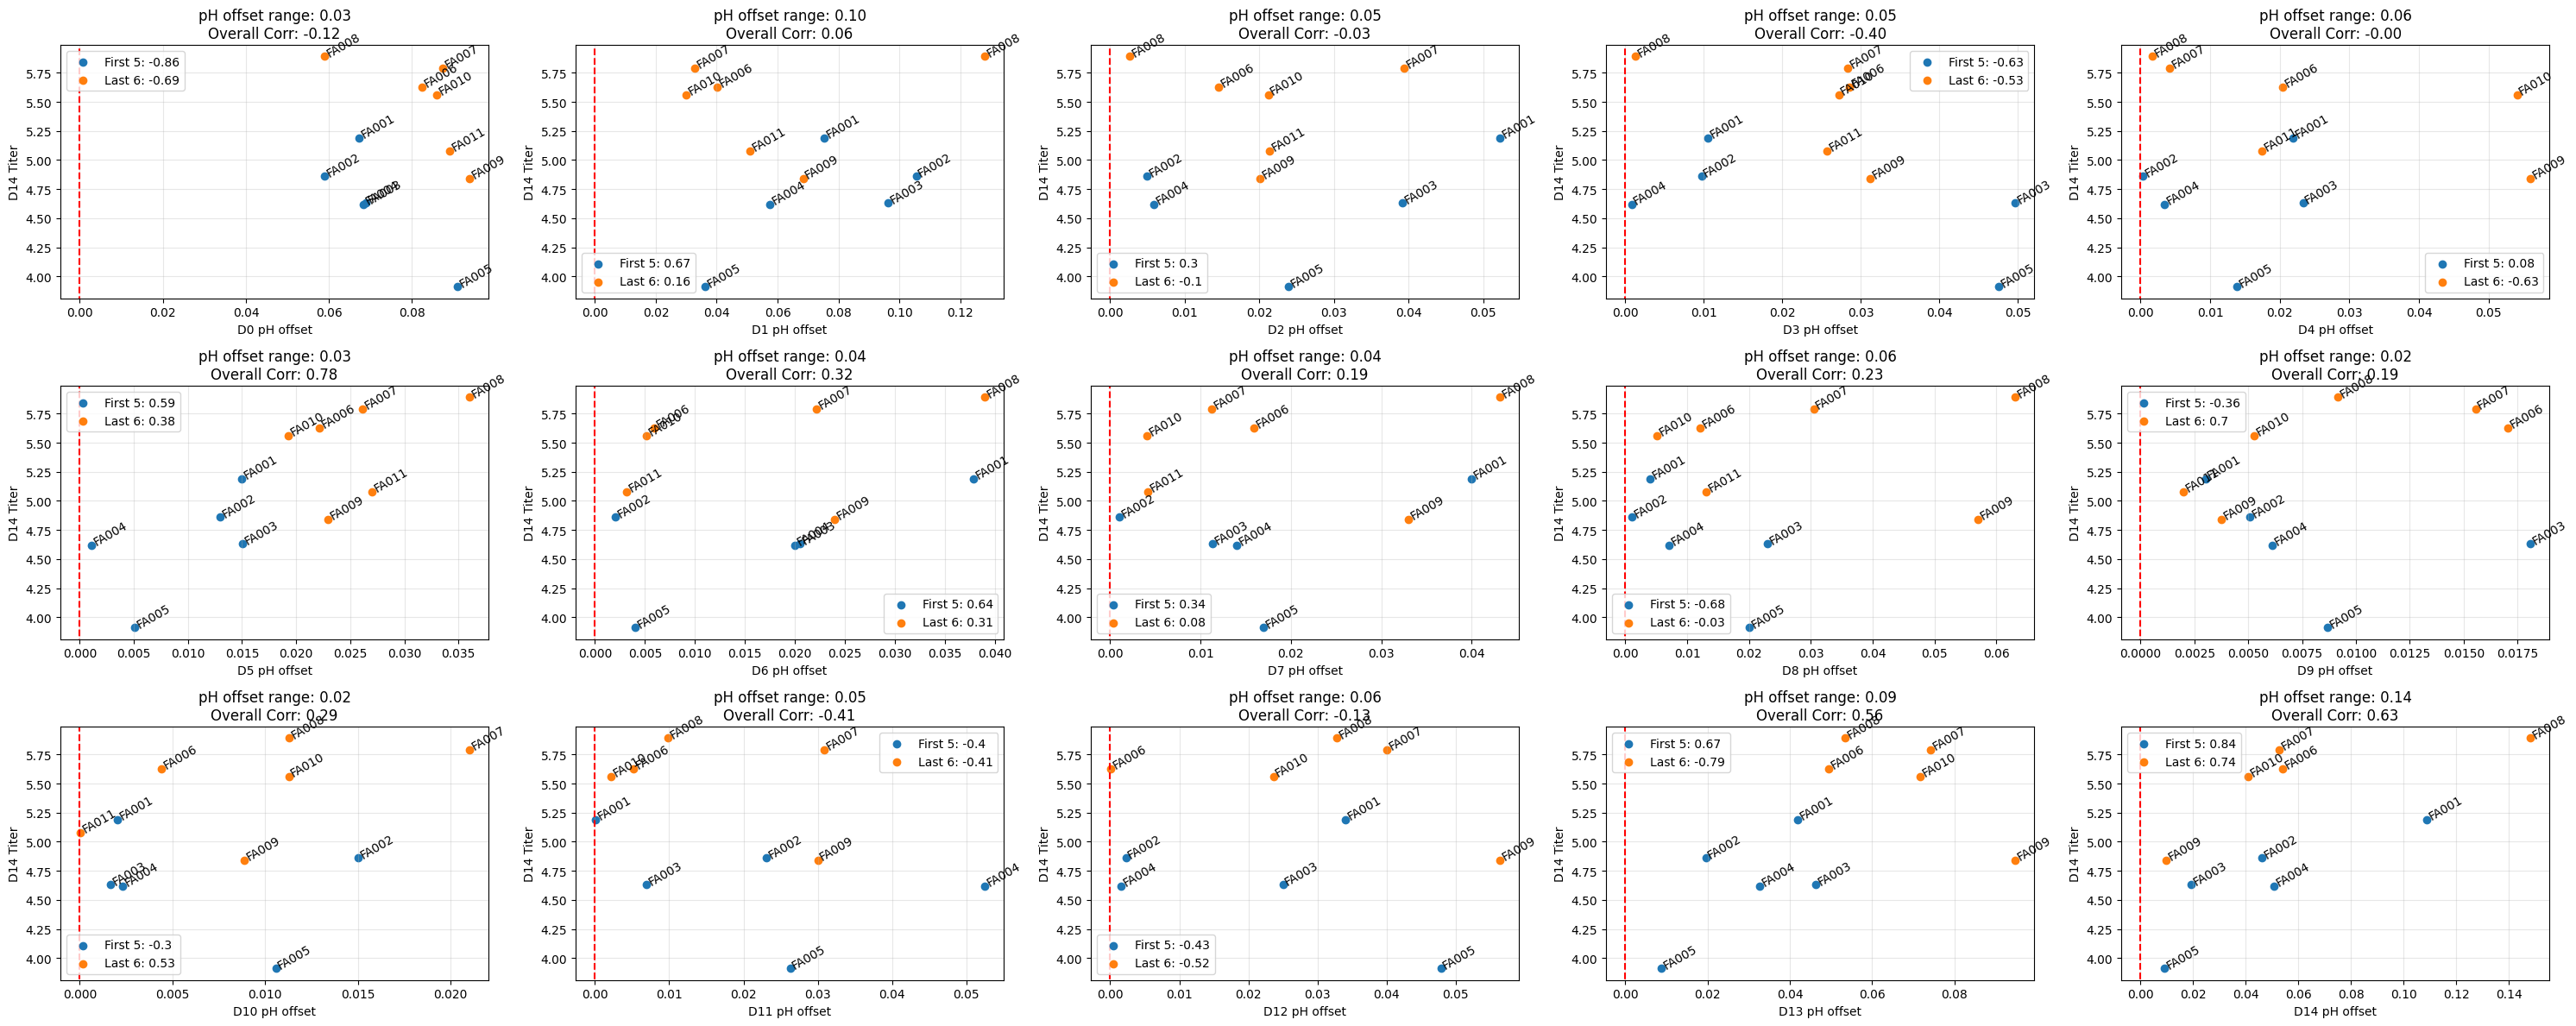

In [11]:
fig, axs = plt.subplots(3, 5, figsize = (30, 12))

feat = "pH offset []"
nstep_ts_agg = nstep_ts.copy()
nstep_ts_agg[feat] = nstep_ts_agg[feat].abs()
nstep_ts_agg = nstep_ts_agg.groupby(["Batch", "Process Day"]).max().reset_index()
nstep_ts_agg = pd.merge(target, nstep_ts_agg, on = "Batch")

first_batches = ["FA001", "FA002", "FA003", "FA004", "FA005"]

for day_idx, day in enumerate(nstep_ts["Process Day"].unique()):

    row_idx = day_idx // 5
    col_idx = day_idx % 5
    ax = axs[row_idx][col_idx]

    sub_df = nstep_ts_agg[nstep_ts_agg["Process Day"] == day].copy()
    sub_df = sub_df.sort_values(by = "Batch")
    # sub_df = nstep_ts[nstep_ts["Batch"] == batch].copy()

    
    # sub_df = sub_df[["Process Day", "Process Time [h]","pH offset []"]]
    # sub_df = sub_df.groupby("Process Day").max().reset_index()
    sub_df = sub_df[~sub_df["pH offset []"].isna()]
    sub_df[feat] = sub_df[feat].abs()

    for row_idx, row in sub_df.iterrows():
        ax.text(row[feat], row["D14 Titer"], row["Batch"], rotation = 30)

    first_df = sub_df[sub_df["Batch"].isin(first_batches)]
    corr = np.corrcoef(first_df[feat].tolist(), first_df["D14 Titer"].tolist())[0, 1]
    ax.scatter(first_df[feat].tolist(), first_df["D14 Titer"].tolist(), label = f"First 5: {round(corr, 2)}")
    
    last_df = sub_df[~sub_df["Batch"].isin(first_batches)]
    corr = np.corrcoef(last_df[feat].tolist(), last_df["D14 Titer"].tolist())[0, 1]
    ax.scatter(last_df[feat].tolist(), last_df["D14 Titer"].tolist(), label = f"Last 6: {round(corr, 2)}")
    
    corr = np.corrcoef(sub_df[feat].tolist(), sub_df["D14 Titer"].tolist())[0, 1]
    
    ax.set_xlabel(f"D{day} pH offset")
    ax.set_ylabel("D14 Titer")
    x_range = sub_df["pH offset []"].max() - sub_df["pH offset []"].min()
    ax.set_title(f"pH offset range: {x_range:.2f}\nOverall Corr: {corr:.2f}")
    ax.legend()

    ax.vlines(0, 0, 10, color = "red", linestyle = "--")
    ax.set_ylim(3.811, 5.989)
    ax.grid(alpha = 0.3)

fig.tight_layout()
fig.show()

In [12]:
aggregate

NameError: name 'aggregate' is not defined

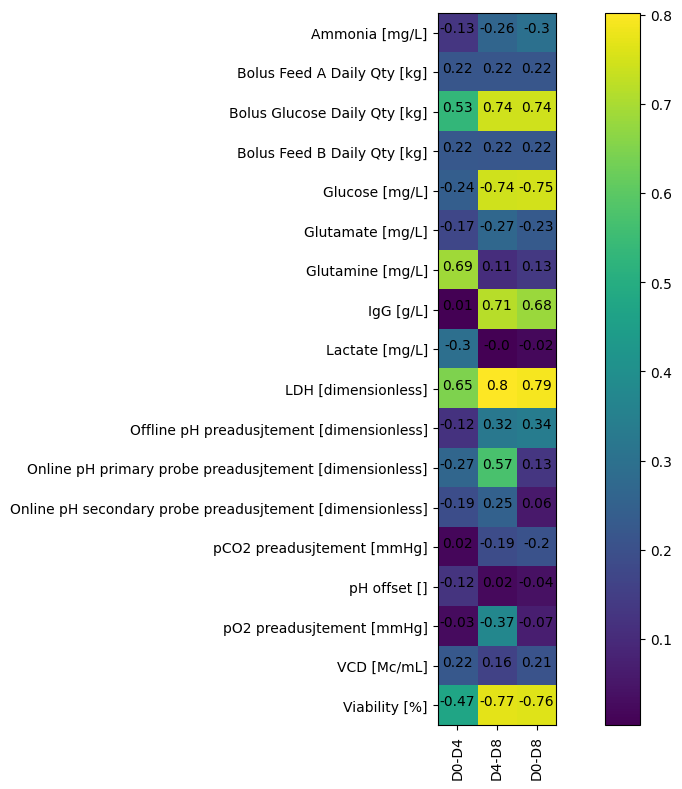

In [13]:
aggregate = nstep_ts.copy()
aggregate.drop(["Run", "Process Time [h]"], axis = 1, inplace = True)

aggregate = aggregate.groupby(["Batch", "Process Day"]).max().reset_index()

agg_1 = aggregate[aggregate["Process Day"] <= 4]
agg_1 = agg_1.groupby("Batch").mean().reset_index()
agg_1 = pd.merge(target, agg_1, on = "Batch")
agg_1.drop("Process Day", axis = 1, inplace = True)
agg_1 = agg_1[agg_1.columns[1:]].corr()["D14 Titer"].tolist()[1:]

agg_2 = aggregate[(aggregate["Process Day"] >= 4) & (aggregate["Process Day"] <= 8)]
agg_2 = agg_2.groupby("Batch").mean().reset_index()
agg_2 = pd.merge(target, agg_2, on = "Batch")
agg_2.drop("Process Day", axis = 1, inplace = True)
agg_2 = agg_2[agg_2.columns[1:]].corr()["D14 Titer"].tolist()[1:]

agg_3 = aggregate[(aggregate["Process Day"] <= 8)]
agg_3 = agg_3.groupby("Batch").mean().reset_index()
agg_3 = pd.merge(target, agg_3, on = "Batch")
agg_3.drop("Process Day", axis = 1, inplace = True)
agg_3 = agg_3[agg_3.columns[1:]].corr()["D14 Titer"].tolist()[1:]

aggs = np.array([agg_1, agg_2, agg_3]).T

plt.figure(figsize = (10, 8))
plt.imshow(np.abs(aggs))
for i in range(aggs.shape[0]):
    for j in range(aggs.shape[1]):
        plt.text(j, i, round(aggs[i, j], 2), horizontalalignment = "center")
plt.xticks(range(3), ["D0-D4", "D4-D8", "D0-D8"], rotation = 90)
plt.yticks(range(18), aggregate.columns[2:])
plt.colorbar()
plt.tight_layout()
plt.show()

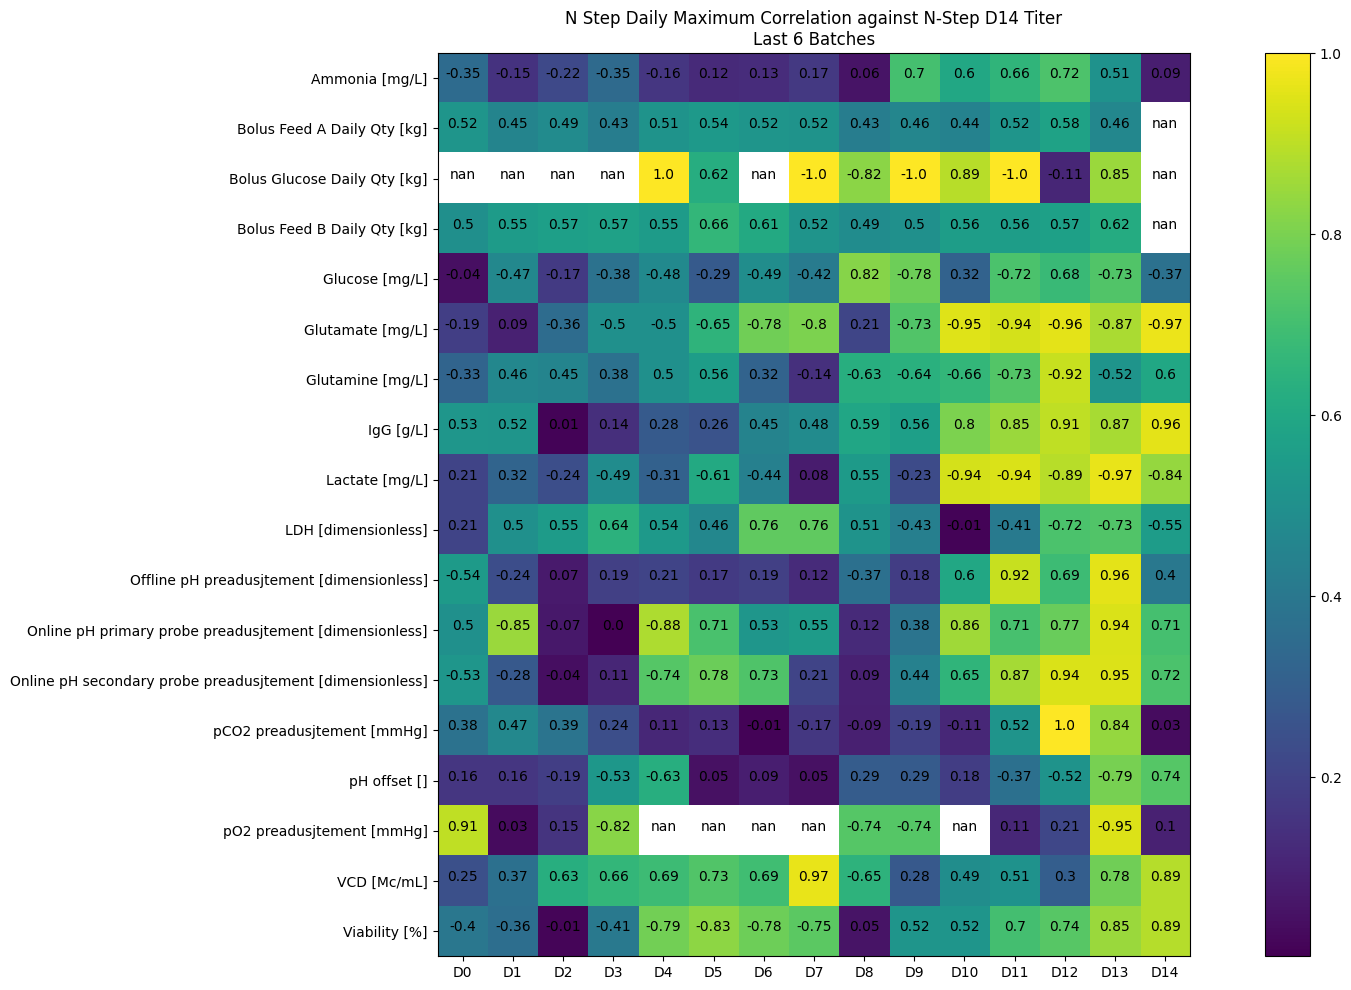

In [19]:
aggregate = nstep_ts.copy()
aggregate.drop(["Run", "Process Time [h]"], axis = 1, inplace = True)

aggregate = aggregate.groupby(["Batch", "Process Day"]).max().reset_index()
aggregate = pd.merge(target, aggregate, on = "Batch")
aggregate = aggregate[["Batch", "Process Day", "D14 Titer"] + aggregate.columns[3:].tolist()]
aggregate = aggregate.sort_values(by = ["Batch", "Process Day"])

last_6 = ["FA001", "FA002", "FA003", "FA004", "FA005"]
last_6 = ["FA006", "FA007", "FA008", "FA009", "FA010", "FA011"]
# last_6 = ["FA001", "FA002", "FA003", "FA004", "FA005", "FA006", "FA007", "FA008", "FA009", "FA010", "FA011"]

corrs = []
for day in aggregate["Process Day"].unique():
    sub_df = aggregate[(aggregate["Process Day"] == day) & (aggregate["Batch"].isin(last_6))][aggregate.columns[2:]]
    corrs.append(sub_df.corr()["D14 Titer"].tolist()[1:])
    
plt.figure(figsize = (16, 10))
corr_mat = np.array(corrs).T
plt.imshow(np.abs(corr_mat))
plt.yticks(range(len(aggregate.columns[3:])), aggregate.columns[3:])
plt.xticks(range(15), [f"D{i}" for i in range(15)])
for i in range(corr_mat.shape[0]):
    for j in range(corr_mat.shape[1]):
        plt.text(j, i, round(corr_mat[i, j], 2), horizontalalignment = "center")
plt.colorbar()
plt.title("N Step Daily Maximum Correlation against N-Step D14 Titer\nLast 6 Batches")
plt.tight_layout()

In [ ]:

last_6 = ["FA001", "FA002", "FA003", "FA004", "FA005"]
last_6 = ["FA006", "FA007", "FA008", "FA009", "FA010", "FA011"]
# last_6 = ["FA001", "FA002", "FA003", "FA004", "FA005", "FA006", "FA007", "FA008", "FA009", "FA010", "FA011"]

corrs = []
for day in aggregate["Process Day"].unique():
    sub_df = aggregate[(aggregate["Process Day"] == day) & (aggregate["Batch"].isin(last_6))][aggregate.columns[2:]]
    corrs.append(sub_df.corr()["D14 Titer"].tolist()[1:])

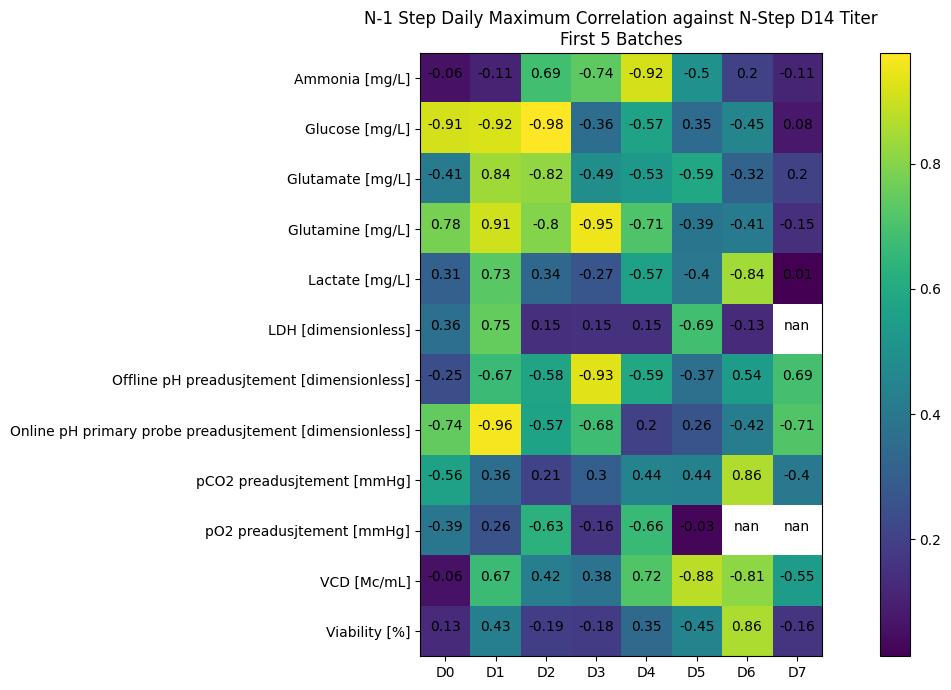

In [22]:
aggregate = nminusstep_ts.copy()
aggregate.drop(["Run", "Process Time [h]"], axis = 1, inplace = True)

aggregate = aggregate.groupby(["Batch", "Process Day"]).max().reset_index()
aggregate = pd.merge(target, aggregate, on = "Batch")
aggregate = aggregate[["Batch", "Process Day", "D14 Titer"] + aggregate.columns[3:].tolist()]
aggregate = aggregate.sort_values(by = ["Batch", "Process Day"])

last_6 = ["FA001", "FA002", "FA003", "FA004", "FA005"]
# last_6 = ["FA006", "FA007", "FA008", "FA009", "FA010", "FA011"]
# last_6 = ["FA001", "FA002", "FA003", "FA004", "FA005", "FA006", "FA007", "FA008", "FA009", "FA010", "FA011"]

corrs = []
for day in aggregate["Process Day"].unique():
    sub_df = aggregate[(aggregate["Process Day"] == day) & (aggregate["Batch"].isin(last_6))][aggregate.columns[2:]]
    corrs.append(sub_df.corr()["D14 Titer"].tolist()[1:])
    
plt.figure(figsize = (12, 7))
corr_mat = np.array(corrs).T
plt.imshow(np.abs(corr_mat))
plt.yticks(range(len(aggregate.columns[3:])), aggregate.columns[3:])
plt.xticks(range(8), [f"D{i}" for i in range(8)])
for i in range(corr_mat.shape[0]):
    for j in range(corr_mat.shape[1]):
        plt.text(j, i, round(corr_mat[i, j], 2), horizontalalignment = "center")
plt.colorbar()
plt.title("N-1 Step Daily Maximum Correlation against N-Step D14 Titer\nFirst 5 Batches")
plt.tight_layout()

## Media

In [ ]:
media = pd.read_csv("./data/media.csv", header = 1)[2:]
media = media[media.columns[1:]]
media = media[media["CAMPAIGN"].apply(lambda x: x.startswith("FA"))].reset_index(drop = True)
media